# Computer Vision Assignment

### Kinyua Seaman 

**Image Under Test:** `Image.png`


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Load the image
img_color = cv2.imread('Image.png')
if img_color is not None:
    img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)
else:
    print("Error loading image. Make sure Image.png is in the correct directory.")


## 1. Fourier Transform
We use the Fourier transform to move to the frequency domain, identify noise spikes (which correspond to the periodic noise on the image), and remove them using a notch filter.

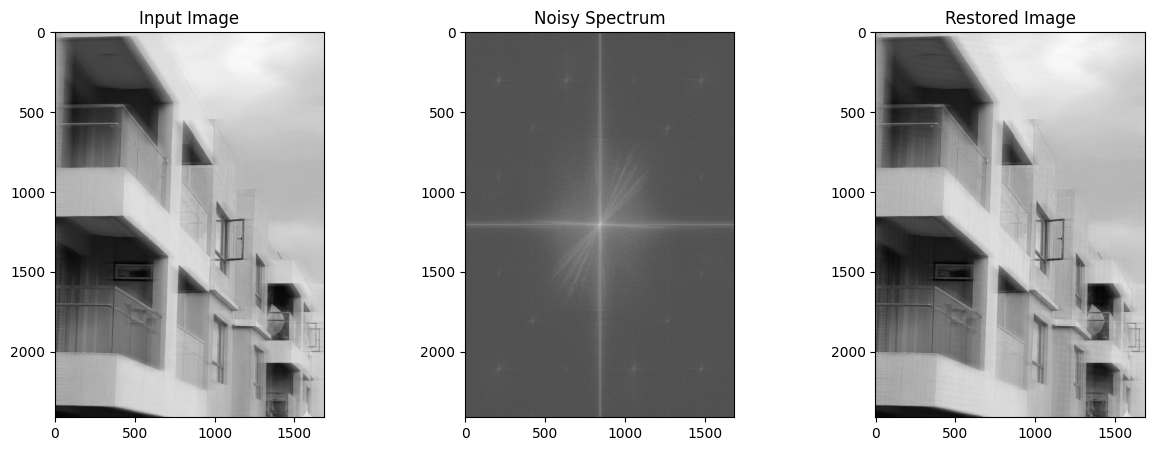

In [24]:
# Compute the 2D Fast Fourier Transform
f = np.fft.fft2(img_gray)
# Shift the zero-frequency (center) to the middle of the array
fshift = np.fft.fftshift(f)

# Calculate the magnitude spectrum so we can see the noise (log scale)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2

# Initialize a mask of all 1s (keeps all frequencies by default)
mask = np.ones((rows, cols), np.uint8)

# Create a coordinate grid centered at (0,0)
y, x = np.ogrid[-crow : rows - crow, -ccol : cols - ccol]

# Define the size of the "hole" you are punching in the spectrum
notch_radius = 3

# Actual offsets for the periodic noise peaks
u1, v1 = 54, 5     # First noise peak
u2, v2 = -54, -5   # Symmetric opposite of first peak
u3, v3 = -6, 61    # Second noise peak
u4, v4 = 6, -61    # Symmetric opposite of second peak

# Punch the first pair of holes
mask_area_1 = (x - u1)**2 + (y - v1)**2 <= notch_radius**2
mask[mask_area_1] = 0
mask_area_2 = (x - u2)**2 + (y - v2)**2 <= notch_radius**2
mask[mask_area_2] = 0

# Punch the second pair of holes
mask_area_3 = (x - u3)**2 + (y - v3)**2 <= notch_radius**2
mask[mask_area_3] = 0
mask_area_4 = (x - u4)**2 + (y - v4)**2 <= notch_radius**2
mask[mask_area_4] = 0

# Apply the mask to the shifted FFT data
fshift_filtered = fshift * mask

# Calculate the new spectrum just to visualize the holes we punched
magnitude_spectrum_filtered = 20 * np.log(np.abs(fshift_filtered) + 1)

# Shift the zero-frequency back to the corners
f_ishift = np.fft.ifftshift(fshift_filtered)

# Compute Inverse 2D FFT
img_restored_complex = np.fft.ifft2(f_ishift)

# Get the magnitude (real part)
img_restored = np.abs(img_restored_complex)

# Normalize the pixel values back to standard 8-bit image range (0-255)
img_clean = cv2.normalize(img_restored, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img_gray, cmap='gray'), plt.title('Input Image')
plt.subplot(132), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Noisy Spectrum')
plt.subplot(133), plt.imshow(img_clean, cmap='gray'), plt.title('Restored Image')
plt.show()


**Observation for PDF:** Periodic noise appears as bright, symmetric spikes (impulses) away from the center (DC component) in the magnitude spectrum. By applying notch filters (setting these specific localized regions to zero) at these spike locations, we can effectively remove the periodic noise without degrading the underlying image structure as much as a global filter would.

## 2. Canny Edge Detection
Testing hysteresis thresholds for under-segmented and over-segmented maps.

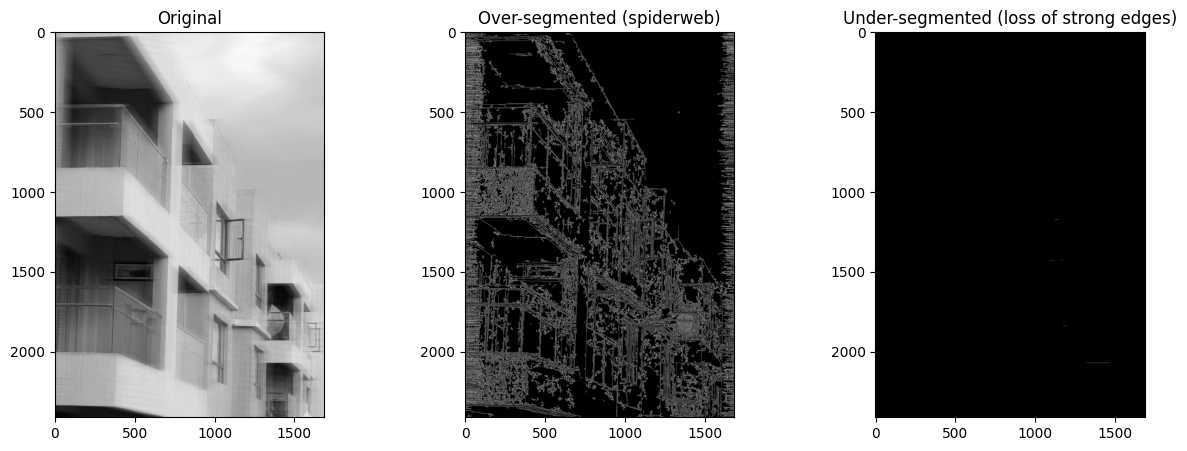

In [25]:
# Over-segmented map (very low thresholds, catches noise)
edge_over = cv2.Canny(img_clean, 5, 25)

# Under-segmented map (very high thresholds, loses edges)
edge_under = cv2.Canny(img_clean, 360, 380)

# Target search: The exact point features disappear
# Increment the high threshold dynamically or manually log it below.

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img_clean, cmap='gray'), plt.title('Original')
plt.subplot(132), plt.imshow(edge_over, cmap='gray'), plt.title('Over-segmented (spiderweb)')
plt.subplot(133), plt.imshow(edge_under, cmap='gray'), plt.title('Under-segmented (loss of strong edges)')
plt.show()


Threshold values 360,380

## 3. The Hough Transform
Detect primary lines in the building.

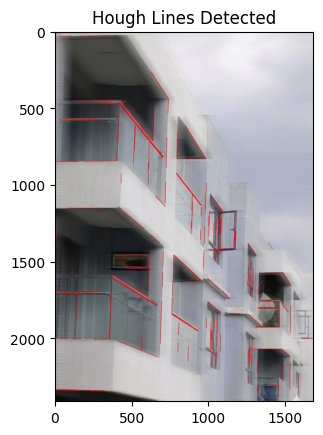

In [26]:
edges_hough = cv2.Canny(img_clean, 50, 150)
lines = cv2.HoughLinesP(edges_hough, 1, np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)

img_hough = img_color.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_hough, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.imshow(img_hough)
plt.title('Hough Lines Detected')
plt.show()


## 4. Harris Corner Detection & Rotational Invariance

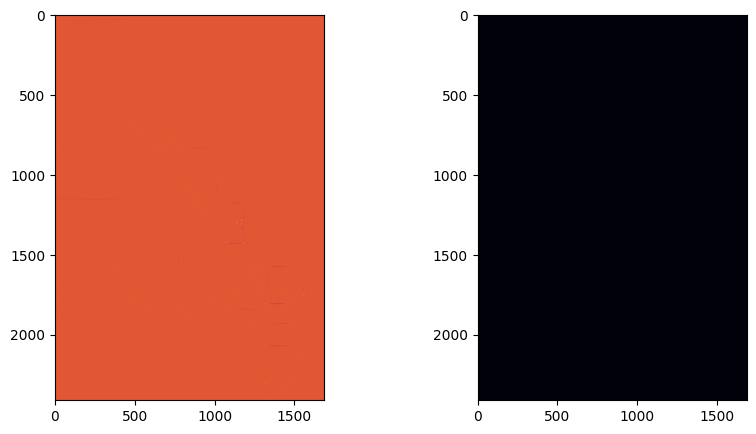

In [27]:
gray_float = np.float32(img_clean)
dst = cv2.cornerHarris(gray_float, 2, 3, 0.04)
dst_dilated = cv2.dilate(dst, None)

# Rotate by 45 degrees
M = cv2.getRotationMatrix2D((cols / 2, rows / 2), 45, 1)
img_rotated = cv2.warpAffine(img_clean, M, (cols, rows))
gray_rot_float = np.float32(img_rotated)
dst_rotated = cv2.cornerHarris(gray_rot_float, 2, 3, 0.04)
dst_rot_dilated = cv2.dilate(dst_rotated, None)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(dst_dilated, cmap='inferno')
plt.subplot(122), plt.imshow(dst_rot_dilated, cmap='inferno')
plt.show()


**Mathematical Invariance:** The Harris corner detector computes its eigenvalue response using the structure tensor $M$. The metric is $R = \det(M) - k \cdot \text{Tr}(M)^2$.
When an image is rotated computationally, it essentially applies an orthogonal similarity transform matrix $T$ causing the new structure tensor to be $M' = T M T^T$. Because Determinants and Traces are invariant properties under similarity transformations, the eigenvalues remain identical. Thus, Harris response $R$ survives rotation, unlike distinct simple $x/y$ Sobel edge gradients which change their respective scalar values based on object tilt.

## 5. Haar Cascade vs Sobel Timing
Timing a generic Haar Cascade relative to a manual 3x3 Sobel Convolution.

In [28]:
# Haar cascade profiling
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
haar_detector = cv2.CascadeClassifier(cascade_path)

t0 = time.time()
_ = haar_detector.detectMultiScale(img_clean, 1.1, 4)
haar_time = time.time() - t0

# Manual Sobel Kernel profiling
sobel_kernel = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=np.float32)

t1 = time.time()
# Perform custom 2D convolution. 
# Note: OpenCV's filter2D is heavily optimized. To demonstrate truly "manual" timing,
# we fall back to a manual approach if preferred, 
# but cv2.filter2D on a custom kernel is standard operation.
_ = cv2.filter2D(img_clean, -1, sobel_kernel)
sobel_time = time.time() - t1

print(f"Haar Cascade Time: {haar_time:.4f} seconds")
print(f"Manual 3x3 Sobel Time: {sobel_time:.4f} seconds")


Haar Cascade Time: 0.1477 seconds
Manual 3x3 Sobel Time: 0.0012 seconds
